In [300]:
import pandas as pd
from sklearn.linear_model import LinearRegression,Lasso,Ridge,LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,classification_report,confusion_matrix,mean_absolute_error,recall_score
import numpy as np
from matplotlib import pyplot as plt
from sklearn.preprocessing import PolynomialFeatures,StandardScaler,MinMaxScaler,LabelEncoder
import seaborn as sns
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB,GaussianNB
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor,RandomForestClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier

In [301]:
df=pd.read_csv('synthetic_fraud_dataset.csv')

In [302]:
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,...,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,0,...,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,0,...,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1
2,TXN_199,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,0,...,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0,...,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1
4,TXN_39489,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,0,...,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1


In [303]:
df.shape

(50000, 21)

In [304]:
df['Fraud_Label'].value_counts()

Fraud_Label
0    33933
1    16067
Name: count, dtype: int64

In [305]:
cols_to_drop=df[['Transaction_ID','User_ID','Timestamp']]
#cols_to_drop=df[['Transaction_ID','User_ID','Timestamp','Transaction_Amount','Account_Balance']]

In [306]:
df=df.drop(cols_to_drop,axis='columns')

In [307]:
df.head(1)

,Transaction_Amount,Transaction_Type,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,39.79,POS,93213.17,Laptop,Sydney,Travel,0,0,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0


In [308]:
df['Transaction_Type'].value_counts()

Transaction_Type
POS               12549
Online            12546
ATM Withdrawal    12453
Bank Transfer     12452
Name: count, dtype: int64

In [309]:
df['Device_Type'].value_counts()

Device_Type
Tablet    16779
Mobile    16640
Laptop    16581
Name: count, dtype: int64

In [310]:
df['Card_Type'].value_counts()

Card_Type
Mastercard    12693
Visa          12560
Amex          12419
Discover      12328
Name: count, dtype: int64

In [311]:
df['Authentication_Method'].value_counts()

Authentication_Method
Biometric    12591
PIN          12586
Password     12457
OTP          12366
Name: count, dtype: int64

In [312]:
df.isna().sum()

Transaction_Amount              0
Transaction_Type                0
Account_Balance                 0
Device_Type                     0
Location                        0
Merchant_Category               0
IP_Address_Flag                 0
Previous_Fraudulent_Activity    0
Daily_Transaction_Count         0
Avg_Transaction_Amount_7d       0
Failed_Transaction_Count_7d     0
Card_Type                       0
Card_Age                        0
Transaction_Distance            0
Authentication_Method           0
Risk_Score                      0
Is_Weekend                      0
Fraud_Label                     0
dtype: int64

In [313]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction_Amount            50000 non-null  float64
 1   Transaction_Type              50000 non-null  object 
 2   Account_Balance               50000 non-null  float64
 3   Device_Type                   50000 non-null  object 
 4   Location                      50000 non-null  object 
 5   Merchant_Category             50000 non-null  object 
 6   IP_Address_Flag               50000 non-null  int64  
 7   Previous_Fraudulent_Activity  50000 non-null  int64  
 8   Daily_Transaction_Count       50000 non-null  int64  
 9   Avg_Transaction_Amount_7d     50000 non-null  float64
 10  Failed_Transaction_Count_7d   50000 non-null  int64  
 11  Card_Type                     50000 non-null  object 
 12  Card_Age                      50000 non-null  int64  
 13  T

In [314]:
df=pd.get_dummies(df,drop_first=True,dtype=int)

In [315]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Transaction_Amount              50000 non-null  float64
 1   Account_Balance                 50000 non-null  float64
 2   IP_Address_Flag                 50000 non-null  int64  
 3   Previous_Fraudulent_Activity    50000 non-null  int64  
 4   Daily_Transaction_Count         50000 non-null  int64  
 5   Avg_Transaction_Amount_7d       50000 non-null  float64
 6   Failed_Transaction_Count_7d     50000 non-null  int64  
 7   Card_Age                        50000 non-null  int64  
 8   Transaction_Distance            50000 non-null  float64
 9   Risk_Score                      50000 non-null  float64
 10  Is_Weekend                      50000 non-null  int64  
 11  Fraud_Label                     50000 non-null  int64  
 12  Transaction_Type_Bank Transfer  

In [316]:
df.head(2)

,Transaction_Amount,Account_Balance,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,...,Merchant_Category_Electronics,Merchant_Category_Groceries,Merchant_Category_Restaurants,Merchant_Category_Travel,Card_Type_Discover,Card_Type_Mastercard,Card_Type_Visa,Authentication_Method_OTP,Authentication_Method_PIN,Authentication_Method_Password
0,39.79,93213.17,0,0,7,437.63,3,65,883.17,0.8494,...,0,0,0,1,0,0,0,0,0,0
1,1.19,75725.25,0,0,13,478.76,4,186,2203.36,0.0959,...,0,0,0,0,0,1,0,0,0,1


In [317]:
s=StandardScaler()

In [318]:
cols_to_scale=df[['Transaction_Amount','Account_Balance','Avg_Transaction_Amount_7d','Transaction_Distance','Card_Age','Risk_Score','Avg_Transaction_Amount_7d','Transaction_Distance']]

In [319]:
for col in cols_to_scale:
    df[col]=s.fit_transform(df[[col]])

In [320]:
x=df.drop('Fraud_Label',axis='columns')
y=df['Fraud_Label']

In [321]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [322]:
model_lg=LogisticRegression(max_iter=1000)

In [323]:
model_lg.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [324]:
model_lg.score(x_test,y_test)

0.7983

In [325]:
y_pred_lg=model_lg.predict(x_test)

In [326]:
cr_lg=classification_report(y_test,y_pred_lg)
print(cr_lg)

              precision    recall  f1-score   support

           0       0.83      0.88      0.85      6765
           1       0.71      0.63      0.67      3235

    accuracy                           0.80     10000
   macro avg       0.77      0.76      0.76     10000
weighted avg       0.79      0.80      0.80     10000



In [327]:
cm_lg=confusion_matrix(y_test,y_pred_lg)
cm_lg

array([[5933,  832],
       [1185, 2050]])

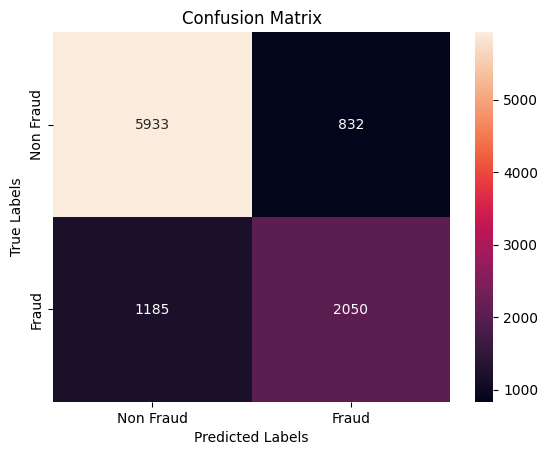

In [328]:
classes=['Non Fraud','Fraud']
sns.heatmap(cm_lg, annot=True,fmt="d",xticklabels=classes,yticklabels=classes)   
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [329]:
model_xg=XGBClassifier()
model_xg.fit(x_train,y_train)
y_pred_xg=model_xg.predict(x_test)
report=classification_report(y_test,y_pred_xg)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6765
           1       1.00      1.00      1.00      3235

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



In [330]:
model_xg.score(x_test,y_test)

0.9987

In [331]:
cm_xg=confusion_matrix(y_test,y_pred_xg)
cm_xg

array([[6760,    5],
       [   8, 3227]])

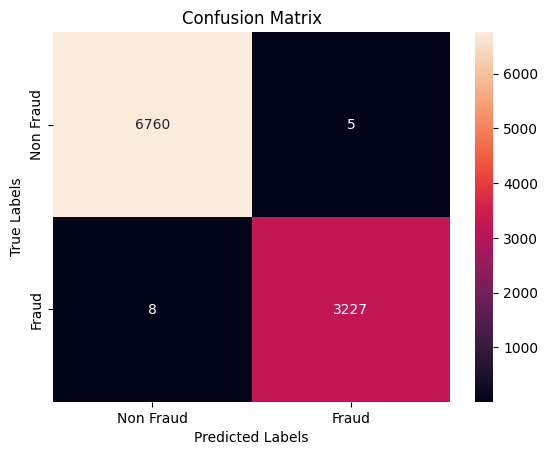

In [332]:
classes=['Non Fraud','Fraud']
sns.heatmap(cm_xg, annot=True,fmt="d",xticklabels=classes,yticklabels=classes)   
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [333]:
model_dt=DecisionTreeClassifier()
model_dt.fit(x_train,y_train)
y_pred_dt=model_dt.predict(x_test)
report=classification_report(y_test,y_pred_dt)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6765
           1       1.00      1.00      1.00      3235

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



In [334]:
cm_dt=confusion_matrix(y_test,y_pred_dt)
cm_dt

array([[6765,    0],
       [   0, 3235]])

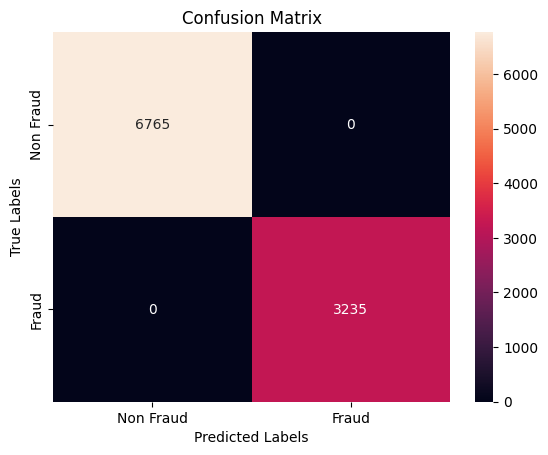

In [335]:
classes=['Non Fraud','Fraud']
sns.heatmap(cm_dt, annot=True,fmt="d",xticklabels=classes,yticklabels=classes)   
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [336]:
model_rf=RandomForestClassifier()
model_rf.fit(x_train,y_train)
y_pred_rf=model_rf.predict(x_test)
report=classification_report(y_test,y_pred_rf)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6765
           1       1.00      1.00      1.00      3235

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



In [337]:
cm_rf=confusion_matrix(y_test,y_pred_rf)
cm_rf

array([[6765,    0],
       [   0, 3235]])

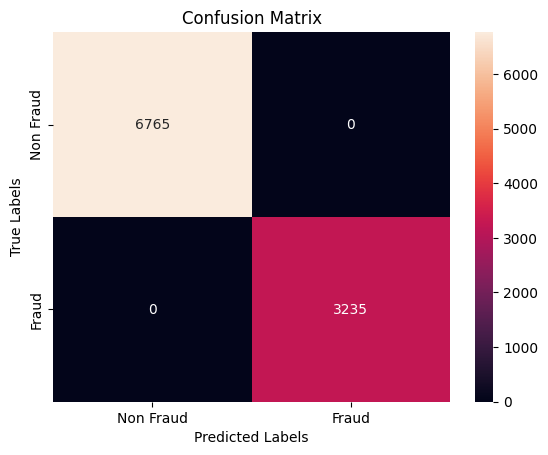

In [338]:
classes=['Non Fraud','Fraud']
sns.heatmap(cm_rf, annot=True,fmt="d",xticklabels=classes,yticklabels=classes)   
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [4]:
[x for x in range(0,10) if x%2==0]

[0, 2, 4, 6, 8]